## Setup

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
cd ..

/home/jovyan/Robbi/dea-coastlines-nextgen


In [5]:
# pip install -e . --quiet

### Dask

In [6]:
import datacube

dc = datacube.Datacube(app="Narrabeen_MNDWI")

from dea_tools.dask import create_local_dask_cluster

client = create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 96,Total memory: 228.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42695,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38983,Total threads: 96
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/36409/status,Memory: 228.00 GiB
Nanny: tcp://127.0.0.1:39321,


In [7]:
# # # Narrabeen Beach, NSW
# lat = (-33.695, -33.715)
# lon = (151.30, 151.320)

# # Narrabeen Beach, NSW
# lat = (-33.75515, -33.67447)
# lon = (151.293, 151.327)

# lat = (-33.781, -33.801)
# lon =(151.283, 151.295)

# lat = (-33.955, -33.941)
# lon = (151.254, 151.261)

# # Broome
# lat = (-17.930, -18.020)
# lon = (122.175, 122.28)

# # Newcastle
# lat = (-32.805, -32.895)
# lon = (151.780, 152.090)

# # Gold Coast (big)
# lon = (153.330, 153.551)
# lat = (-28.170, -27.935)

# Gold Coast (small)
lon = (153.403468, 153.439819)
lat = (-28.109015, -27.929234)

# # Mackay
# lat = (-21.255, -21.135)
# lon = (149.185, 149.23)

# # Point Stuart
# lat = (-12.27662, -12.20973)
# lon = (131.77166, 131.90943)

# # Perth beaches
# lat = (-32.15, -31.85)
# lon = (115.72, 115.78)

# # Perth Tern Island
# lat = (-32.42561, -32.25331)
# lon = (115.67894, 115.76227)

# # Cervantes
# lat = (-30.520, -30.480)
# lon = (115.045, 115.085)

# # Carnarvon
# lat = (-24.920, -24.885)
# lon = (113.615, 113.700)

# # Port Headland
# lat = (-20.357602, -20.290117)
# lon = (118.457062, 118.701694)

# # Trial Bay Gaol Beach, NSW
# lat = (-30.888, -30.877)
# lon = (153.040, 153.080)

# # Shallow Inlet, VIC
# lat = (-38.90300, -38.780)
# lon = (146.120, 146.21600)

# # Woody Head, NSW
# lat = (-29.375, -29.355)
# lon = (153.360, 153.378)

# # Byron Bay, NSW
# lat = (-28.670, -28.610)
# lon = (153.590, 153.645)

# # Seal Rocks, NSW
# lat = (-32.32, -32.455)
# lon = (152.48754, 152.56999)

# Lancelin, WA
lat = (-31.040, -30.980)
lon = (115.310, 115.345)

# # Cervantes, WA
# lat = (-30.520, -30.480)
# lon = (115.045, 115.085)

# # Port Denison, WA
# lat = (-29.285, -29.255)
# lon = (114.910, 114.935)

# # Inverloch, VIC
# lat = (-38.670, -38.635)
# lon = (145.700, 145.765)

# # # Bribie Island, QLD
# lat =  (-26.791594, -26.87520)
# lon = (153.117927, 153.15748)

# ## Towra Point, NSW
# lat = (-33.98, -34.02)
# lon = (151.14, 151.16)

# # # Cronulla, NSW
# lat = (-34.035, -34.06)
# lon = (151.15, 151.205)

# Set dates
start_date = "2025-07-01"
end_date = "2026-07-01"

In [ ]:
# query = {
#     "y": lat,
#     "x": lon,
#     "time": (start_date, end_date),
#     "cloud_cover": (0, 80),
#     # 'output_crs': 'EPSG:3577',  # Australian Albers
#     "resolution": (-10, 10),
#     "measurements": [
#         "nbart_green",
#         "nbart_swir_2",
#         "nbart_blue",
#         "nbart_nir_1",
#         # "oa_s2cloudless_mask",
#         "oa_s2cloudless_prob",
#     ],
#     "resampling": {"*": "cubic", "oa_s2cloudless_mask": "nearest"},
#     "group_by": "solar_day",
#     "dask_chunks": {"time": 1, "y": 2048, "x": 2048},
# }

# # Pass a list to `product` to seamlessly load and merge S2
# ds = dc.load(product=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"], **query)

# # Mask clouds
# # valid_pixels = ds.oa_s2cloudless_mask.isin([1])
# valid_pixels = ds.oa_s2cloudless_prob < 0.8

# # Apply the mask and drop the standard nodata values (-999)
# ds_clean = ds[["nbart_green", "nbart_swir_2", "nbart_blue", "nbart_nir_1"]].where(
#     valid_pixels
# )
# ds_clean = ds_clean.where(ds_clean != -999)

# # Calculate MNDWI: (Green - SWIR1) / (Green + SWIR1)
# mndwi = (ds_clean.nbart_green - ds_clean.nbart_swir_2) / (ds_clean.nbart_green + ds_clean.nbart_swir_2)
# # mndwi = (
# #     (ds_clean.nbart_green + ds_clean.nbart_blue)
# #     - (ds_clean.nbart_nir_1 + ds_clean.nbart_swir_2)
# # ) / (
# #     (ds_clean.nbart_green + ds_clean.nbart_blue)
# #     + (ds_clean.nbart_nir_1 + ds_clean.nbart_swir_2)
# # )
# mndwi.load()
# mndwi.isel(time=0).plot(robust=True)

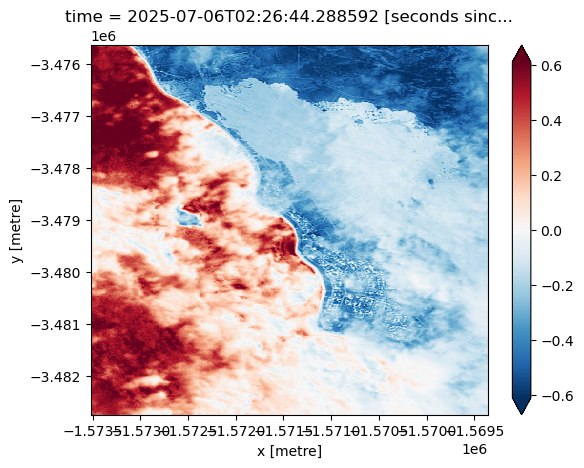

In [8]:
query = {
    "y": lat,
    "x": lon,
    "time": (start_date, end_date),
    "resolution": (-10, 10),
    "measurements": [
        "nbart_green",
        "nbart_swir_2",
        "nbart_blue",
        "nbart_nir_1",
        "oa_s2cloudless_prob",
    ],
    "resampling": {"*": "cubic", "oa_s2cloudless_mask": "nearest", "oa_s2cloudless_prob": "nearest"},
    "group_by": "solar_day",
    "dask_chunks": {"time": 1, "y": 2048, "x": 2048},
}

# Pass a list to `product` to seamlessly load and merge S2
ds = dc.load(product=["ga_s2am_ard_3", "ga_s2bm_ard_3", "ga_s2cm_ard_3"], **query)

# Address nodata on spectral bands
spectral_bands = ["nbart_green", "nbart_swir_2", "nbart_blue", "nbart_nir_1"]
ds[spectral_bands] = ds[spectral_bands].where(ds != -999)

# Calculate MNDWI: (Green - SWIR1) / (Green + SWIR1)
# mndwi_all = (ds.nbart_green - ds.nbart_swir_2) / (ds.nbart_green + ds.nbart_swir_2)
mndwi_all = (
    (ds.nbart_green + ds.nbart_blue)
    - (ds.nbart_nir_1 + ds.nbart_swir_2)
) / (
    (ds.nbart_green + ds.nbart_blue)
    + (ds.nbart_nir_1 + ds.nbart_swir_2)
)
mndwi_all.isel(time=1).plot(robust=True)

In [9]:
import numpy as np
from odc.algo import xr_quantile, mask_cleanup

# Load into memory
ds.oa_s2cloudless_prob.persist()

# Calculate persistent misclassified cloud threshold
thresh = xr_quantile(
    ds[["oa_s2cloudless_prob"]], [0.2], nodata=np.nan
).oa_s2cloudless_prob.squeeze()

# Create custom cloud mask and clean
cloud_mask = ds.oa_s2cloudless_prob > (0.4 + thresh).clip(0, 0.90)
cloud_mask = mask_cleanup(cloud_mask, mask_filters=[("opening", 6), ("dilation", 3)])

# Estimate cloud percent, apply mask and load
cloud_perc = cloud_mask.where(ds.oa_s2cloudless_prob.notnull()).mean(dim=["x", "y"])

# Apply custom mask and drop particularly cloudy scenes
mndwi = mndwi_all.where(~cloud_mask).sel(time=cloud_perc < 0.8)

# Load data
mndwi.load()

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.DataArray (time: 69, y: 710, x: 416)> Size: 82MB
array([[[        nan,         nan,         nan, ..., -0.28180602,
         -0.29264593, -0.29083812],
        [        nan,         nan,         nan, ..., -0.28471953,
         -0.29207635, -0.2764197 ],
        [        nan,         nan,         nan, ..., -0.29001772,
         -0.2994462 , -0.27882037],
        ...,
        [        nan,         nan,         nan, ..., -0.48144722,
         -0.48260564, -0.45447817],
        [        nan,         nan,  0.30146083, ..., -0.5021305 ,
         -0.49349254, -0.4792977 ],
        [ 0.18642297,  0.25977302,  0.29395974, ..., -0.5005557 ,
         -0.5110235 , -0.49827996]],

       [[ 0.6002886 ,  0.5844346 ,  0.55221635, ...,         nan,
                 nan,         nan],
        [ 0.597783  ,  0.57296467,  0.54      , ...,         nan,
                 nan,         nan],
        [ 0.5700326 ,  0.5371384 ,  0.541112  , ...,         nan,
                 nan,         nan],
...
        [ 0.38706467,  0.36703742,  0.34365326, ..., -0.46469763,
         -0.45512608, -0.42909676],
        [ 0.4027778 ,  0.37931034,  0.38353413, ..., -0.47638044,
         -0.45480856, -0.4331551 ],
        [ 0.40295565,  0.37864077,  0.37984496, ..., -0.47069272,
         -0.45438018, -0.47421092]],

       [[ 0.86988455,  0.82590234,  0.802381  , ..., -0.5613369 ,
         -0.54208755, -0.5549924 ],
        [ 0.88221973,  0.8226371 ,  0.7849711 , ..., -0.5680843 ,
         -0.5656451 , -0.54305106],
        [ 0.88046956,  0.87118644,  0.8327759 , ..., -0.5810641 ,
         -0.5789033 , -0.5518952 ],
        ...,
        [ 0.9166667 ,  0.9862543 ,  0.9746835 , ..., -0.53166777,
         -0.5162606 , -0.47542104],
        [ 0.96710527,  0.9299363 ,  0.9482201 , ..., -0.55      ,
         -0.516387  , -0.49573812],
        [ 0.9326599 ,  0.91752577,  0.9189189 , ..., -0.53095764,
         -0.5183739 , -0.5364186 ]]], shape=(69, 710, 416), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 552B 2025-07-04T02:26:48.218898 ... 20...
  * y            (y) float64 6kB -3.476e+06 -3.476e+06 ... -3.483e+06 -3.483e+06
  * x            (x) float64 3kB -1.574e+06 -1.574e+06 ... -1.569e+06 -1.569e+06
    spatial_ref  int32 4B 3577
    quantile     float64 8B 0.2

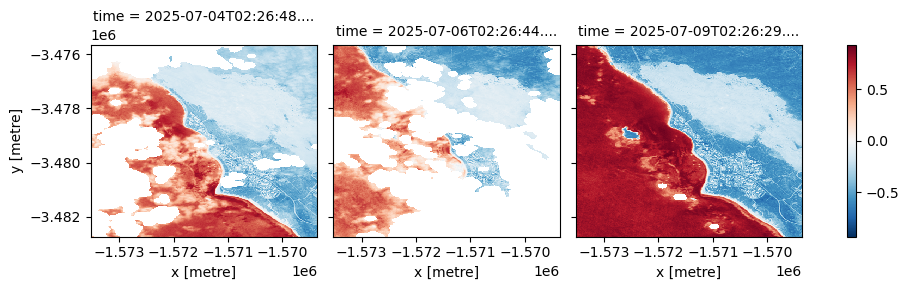

In [10]:
mndwi.isel(time=slice(0, 3)).plot(col="time", col_wrap=3)

## Preprocess

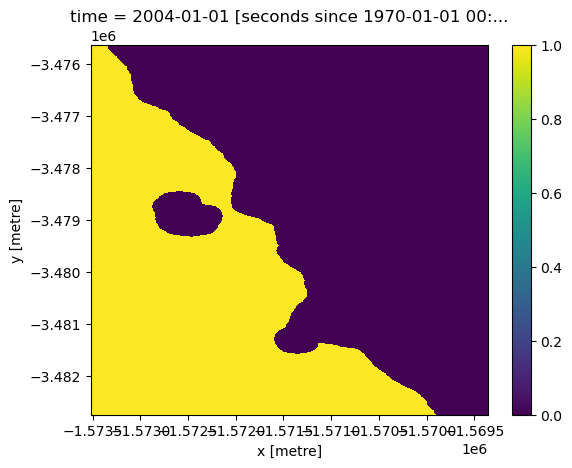

In [11]:
from odc.algo import mask_cleanup

geodata_da = dc.load(
    product="geodata_coast_100k",
    like=mndwi.odc.geobox,
).land.squeeze("time")

ocean_da = mask_cleanup(geodata_da == 0, mask_filters=[("erosion", 20)])
ocean_da.plot()

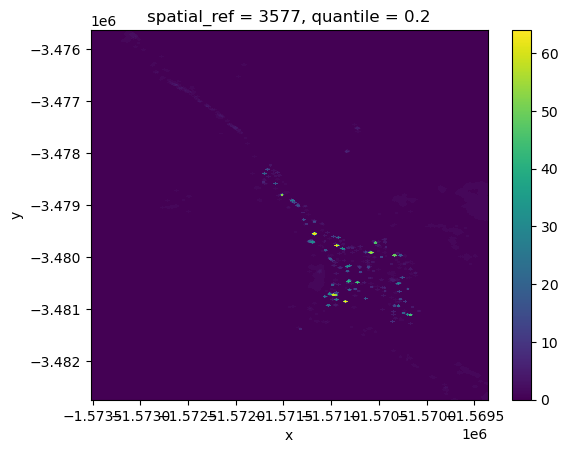

In [13]:
from coastlines.preprocess import inland_water_masking, create_coastal_buffer

inland_water_mask = inland_water_masking(water_mask=mndwi > 0, ocean_mask=ocean_da, dilation=2)
inland_water_mask.sum(dim="time").plot()

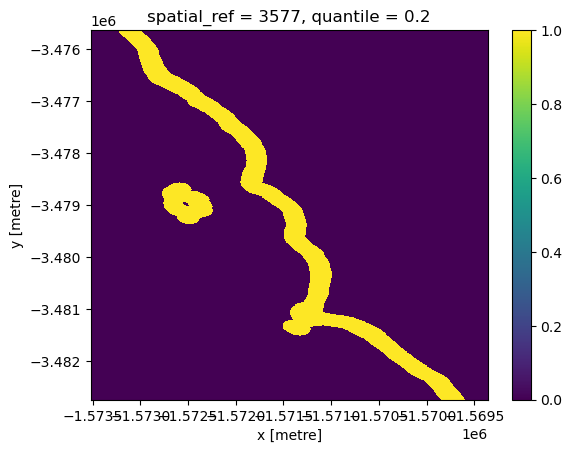

In [14]:
coastal_mask, freq = create_coastal_buffer(mndwi, inland_water_mask, dilation_pixels=10, sieve_size=9)
coastal_mask.astype(int).odc.write_cog("data/coastal_mask.tif", overwrite=True)
freq.odc.write_cog("data/frequency.tif", overwrite=True)
coastal_mask.plot()

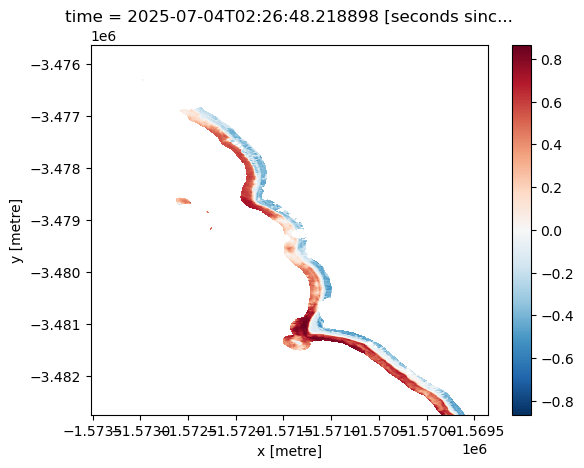

In [15]:
mndwi_cleaned = mndwi.where(~inland_water_mask).where(coastal_mask).dropna(dim="time", how="all")
mndwi_cleaned.isel(time=0).plot()

## Analysis

### Model tides

In [16]:
from eo_tides.eo import pixel_tides, tag_tides
# tides_da = tag_tides(mndwi_cleaned, directory="/var/share/tide_models/", model="EOT20")
tides_da = pixel_tides(mndwi_cleaned, directory="/var/share/tide_models/", model="ensemble")
tides_da

Creating reduced resolution 5000 x 5000 metre tide modelling array
Running ensemble tide modelling
Modelling tides with EOT20, FES2012, FES2014_extrapolated, FES2022_extrapolated, GOT4.10, GOT5.6_extrapolated, TPXO10-atlas-v2-nc, TPXO8-atlas-nc, TPXO9-atlas-v5-nc in parallel (models: 9, splits: 1)


100%|██████████| 9/9 [00:24<00:00,  2.72s/it]


Interpolating model rankings using IDW interpolation 
Combining models into single ensemble model
Reprojecting tides into original resolution


<xarray.DataArray 'tide_height' (time: 69, y: 710, x: 416)> Size: 82MB
array([[[0.04320367, 0.04320367, 0.04320367, ..., 0.04321073,
         0.04321075, 0.04321077],
        [0.04320366, 0.04320366, 0.04320366, ..., 0.04321074,
         0.04321076, 0.04321078],
        [0.04320365, 0.04320365, 0.04320365, ..., 0.04321075,
         0.04321077, 0.0432108 ],
        ...,
        [0.04321063, 0.04321058, 0.04321052, ..., 0.04328146,
         0.0432817 , 0.04328195],
        [0.04321012, 0.04321006, 0.04321   , ..., 0.04328173,
         0.04328198, 0.04328223],
        [0.04320961, 0.04320955, 0.04320949, ..., 0.04328201,
         0.04328226, 0.04328251]],

       [[0.07392465, 0.07392465, 0.07392465, ..., 0.07397626,
         0.07397642, 0.07397658],
        [0.07392475, 0.07392475, 0.07392475, ..., 0.07397652,
         0.07397668, 0.07397684],
        [0.07392485, 0.07392485, 0.07392485, ..., 0.07397678,
         0.07397694, 0.07397711],
...
        [0.26768693, 0.2676868 , 0.26768667, ..., 0.27085495,
         0.27086514, 0.27087536],
        [0.26769543, 0.2676953 , 0.2676952 , ..., 0.2708594 ,
         0.27086958, 0.27087978],
        [0.2677039 , 0.2677038 , 0.2677037 , ..., 0.27086386,
         0.27087402, 0.27088422]],

       [[0.07090067, 0.07090067, 0.07090067, ..., 0.0708891 ,
         0.07088906, 0.07088903],
        [0.0709006 , 0.0709006 , 0.0709006 , ..., 0.07088899,
         0.07088895, 0.07088891],
        [0.07090053, 0.07090053, 0.07090053, ..., 0.07088888,
         0.07088884, 0.0708888 ],
        ...,
        [0.07075901, 0.07075869, 0.07075837, ..., 0.06938086,
         0.06937655, 0.06937223],
        [0.07075422, 0.07075389, 0.07075356, ..., 0.06937916,
         0.06937485, 0.06937055],
        [0.07074944, 0.0707491 , 0.07074875, ..., 0.06937745,
         0.06937316, 0.06936887]]], shape=(69, 710, 416), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 552B 2025-07-04T02:26:48.218898 ... 20...
    tide_model   <U8 32B 'ensemble'
  * y            (y) float64 6kB -3.476e+06 -3.476e+06 ... -3.483e+06 -3.483e+06
  * x            (x) float64 3kB -1.574e+06 -1.574e+06 ... -1.569e+06 -1.569e+06
    spatial_ref  int32 4B 3577

### Calculate SDF

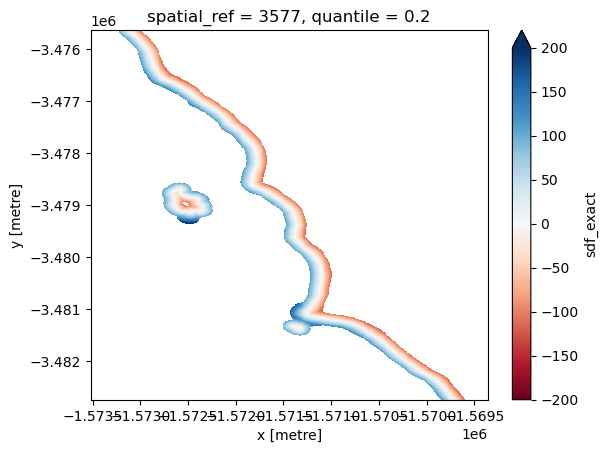

In [20]:
from coastlines.timeseries import exact_subpixel_sdf

sdf_da = mndwi_cleaned.groupby("time").map(exact_subpixel_sdf)
sdf_da.median(dim="time").plot(vmin=-200, vmax=200, cmap="RdBu")

### Estimate slope

#### Theil Sen

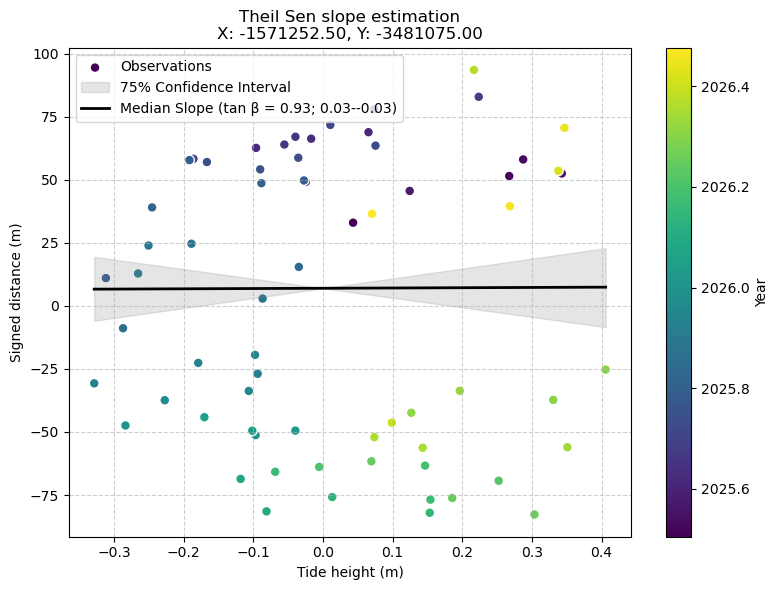

In [28]:
from coastlines.timeseries import theilsen_beach_slope
from coastlines.utils import plot_pixel_regression

# Select input data
# input_tides = tides_da_filtered
# input_sdf = sdf_da_filtered
input_tides = tides_da
input_sdf = sdf_da

# Plot example 
x, y = -1571252.5,-3481075.0
plot_pixel_regression(
    tide_heights=input_tides,
    sdf_stack=input_sdf,
    x_coord=x,
    y_coord=y,
    # y_limits="auto",
    color_by_time=True,
    alpha=0.75,
)


In [ ]:
# # Run in parallel via Dask
# ts_prob = theilsen_beach_slope(
#     sdf_stack=input_sdf.chunk({"y": 256, "x": 256}),
#     tide_heights=input_tides,
#     smooth_window=5,
# )
# ts_prob = ts_prob.where(ts_prob.slope_optimal > 0).compute()

In [ ]:
# ts_prob[["slope_low", "slope_optimal", "slope_high"]].to_array().plot(col="variable", vmin=0, vmax=0.20, cmap="YlOrRd")

In [ ]:
# ts_prob.slope_uncertainty.plot(vmin=0, vmax=0.2, cmap="inferno")

In [ ]:
# ts_prob.slope_optimal.odc.write_cog("ts_slope.tif", overwrite=True)
# ts_prob.intercept.odc.write_cog("ts_intercept.tif", overwrite=True)
# ts_prob.slope_uncertainty.odc.write_cog("ts_slope_uncertainty.tif", overwrite=True)
# uncert_perc = (ts_prob.slope_uncertainty / ts_prob.slope_optimal)
# uncert_perc.odc.write_cog("ts_slope_uncertainty_perc.tif", overwrite=True)
# # ts_prob.slope_optimal.where(uncert_perc < 0.5).odc.write_cog("ts_slope_good.tif", overwrite=True)

#### Variance minimisation

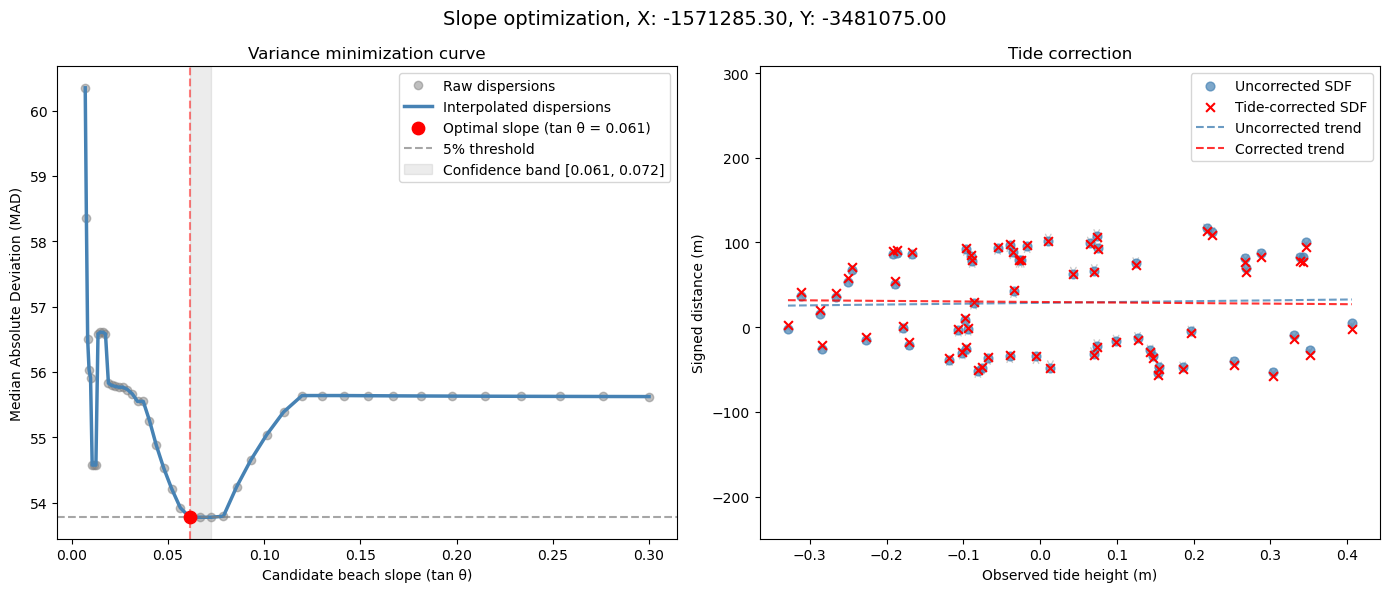

In [57]:
from coastlines.timeseries import _block_theil_sen, slope_variance, extract_optimal_slopes
from coastlines.utils import plot_slope_variance

# Plot example 
x, y = -1571285.3,-3481075.0  # outlier in beach slope deviation
plot_slope_variance(
    tide_heights=input_tides,
    sdf_stack=input_sdf,
    x_coord=x,
    y_coord=y,
    # candidate_slopes=np.geomspace(0.005, 0.30, num=50),
    interp_density=0,
    # interp_method="quadratic",
)

# {"linear", "nearest", "zero", "slinear", "quadratic", "cubic", "quintic", "polynomial", "pchip", "barycentric", "krogh", "akima", "makima"}

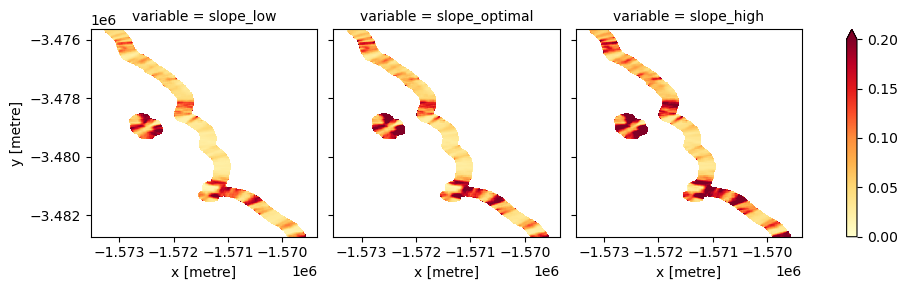

In [39]:
# Create lazy slope dispersion grid-search output
lazy_dispersion = slope_variance(
    sdf_stack=input_sdf.chunk({"x": 200, "y": 200, "time": -1}),
    tide_heights=input_tides.chunk({"x": 200, "y": 200, "time": -1}),
    candidate_slopes=np.geomspace(0.005, 0.30, num=50),
    coastal_mask=coastal_mask
)

# Load into memory
computed_dispersion = lazy_dispersion.compute()

# Extract slope after interpolating and smoothing
var_prob = extract_optimal_slopes(
    dispersion=computed_dispersion,
    confidence_band=0.05,
    smooth_window=9,
    # interp_density=100,
    interp_density=0,
    # interp_method="cubic",
)

# Export rasters
var_prob.slope_optimal.odc.write_cog("data/var_slope.tif", overwrite=True)
var_prob.slope_uncertainty.odc.write_cog("data/var_slope_uncertainty.tif", overwrite=True)
uncert_perc = (var_prob.slope_uncertainty / var_prob.slope_optimal)
uncert_perc.odc.write_cog("data/var_slope_uncertainty_perc.tif", overwrite=True)

# Plot output
var_prob[["slope_low", "slope_optimal", "slope_high"]].to_array().plot(col="variable", vmin=0, vmax=0.20, cmap="YlOrRd")


### Tide correction

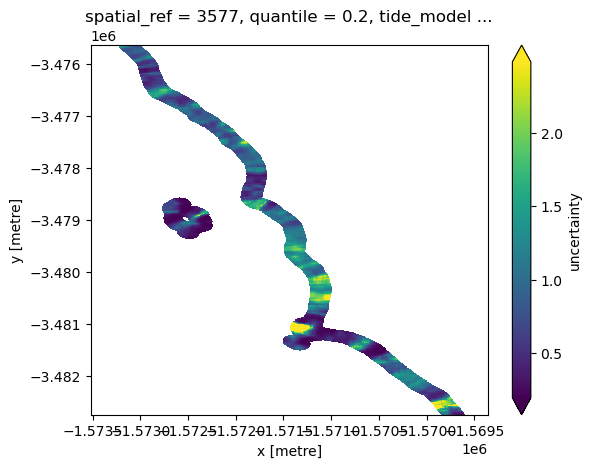

In [42]:
from coastlines.timeseries import apply_tide_correction

datum = 0

sdf_corrected = apply_tide_correction(
    sdf_stack=input_sdf,
    tide_heights=input_tides,
    slope_map = var_prob[["slope_optimal", "slope_low", "slope_high"]].to_array("slope_correction"),
    # slope_map=ts_prob.slope_optimal,
    tide_datum=datum,
).to_dataset(dim="slope_correction")

sdf_corrected["uncertainty"] = abs(sdf_corrected.slope_high - sdf_corrected.slope_low)
sdf_corrected["uncertainty"].mean(dim="time").plot(robust=True)

#### Monthly shorelines

Operating in single z-value, multiple arrays mode
Writing contours to data/shorelines_original_monthly.geojson


<Axes: >

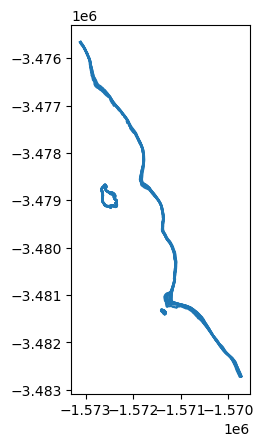

In [46]:
from dea_tools.spatial import subpixel_contours

counts_monthly = sdf_corrected.slope_optimal.notnull().resample(time="MS").sum()
count_mask = counts_monthly >= 3
sdf_original_monthly = sdf_da.resample(time="MS").median().where(count_mask)
sdf_corrected_monthly = sdf_corrected.slope_optimal.resample(time="MS").median().where(count_mask)
sdf_uncertainty_monthly = sdf_corrected.uncertainty.resample(time="MS").median().where(count_mask)

subpixel_contours(
    sdf_original_monthly,
    output_path=f"data/shorelines_original_monthly.geojson",
    min_vertices=20,
).plot()


In [59]:
from coastlines.shorelines import vectorise_uncertainty, shoreline_uncertainty

# Extract all continuous shorelines across the entire time dimension
# Assumes this returns a GeoDataFrame with a 'time' column
shorelines = subpixel_contours(
    sdf_corrected_monthly,
    min_vertices=20,
)

# Convert the 3D uncertainty array into a dictionary of monthly polygon masks
certainty_polygons = vectorise_uncertainty(
    sdf_uncertainty_monthly,
    counts_monthly,
    uncertainty_threshold=5.0,
    count_threshold=3,
    sieve_size=10
)

# Chop the continuous shorelines into attributed segments by matching timestamps
attributed_shorelines = shoreline_uncertainty(
    shorelines, 
    certainty_polygons,
)
attributed_shorelines.to_file(f"data/shorelines_corrected_monthly_{datum}m.geojson")

Operating in single z-value, multiple arrays mode


In [48]:
import smoothify
from dea_tools.spatial import xr_vectorize

sdf_q = sdf_corrected.slope_optimal.quantile(dim="time", q=[0.05, 0.95])
bounds = ((sdf_q.isel(quantile=1) >= 0) & (sdf_q.isel(quantile=0) <= 0))
features = xr_vectorize(da=bounds, mask=bounds !=0)

gdf_smooth = smoothify.smoothify(features)
gdf_smooth.to_crs("EPSG:4326").to_file("data/bounds.geojson")

/env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [ ]:
# from dea_tools.spatial import subpixel_contours

# count_mask_quarterly = sdf_corrected.notnull().resample(time="QS").sum() >= 3
# sdf_original_quarterly = sdf_da.resample(time="QS").median().where(count_mask_quarterly)
# sdf_corrected_quarterly = sdf_corrected.resample(time="QS").median().where(count_mask_quarterly)

# subpixel_contours(
#     sdf_original_quarterly,
#     output_path=f"shorelines_original_quarterly.geojson",
#     min_vertices=20,
# ).plot()

# subpixel_contours(
#     sdf_corrected_quarterly,
#     output_path=f"shorelines_corrected_quarterly_{datum}m.geojson",
#     min_vertices=20,
# ).plot()

### Rates of change

In [62]:
from coastlines.shorelines import rate_change_theilsen

rate_change_corrected = rate_change_theilsen(sdf_stack=sdf_corrected_monthly, alpha=0.9)
rate_change_original = rate_change_theilsen(sdf_stack=sdf_original_monthly, alpha=0.9)

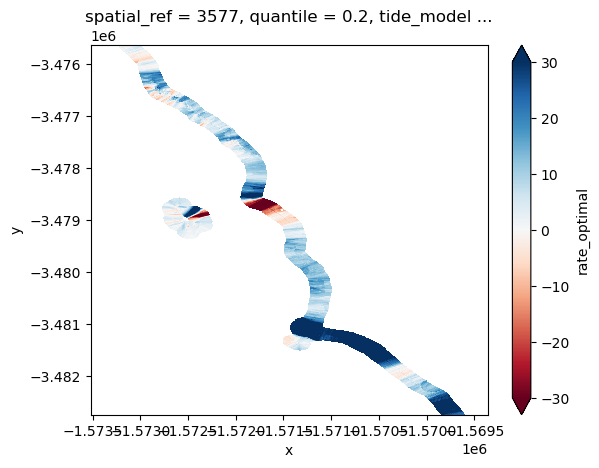

In [51]:
rate_change_corrected.rate_optimal.plot(vmin=-30, vmax=30, cmap="RdBu")

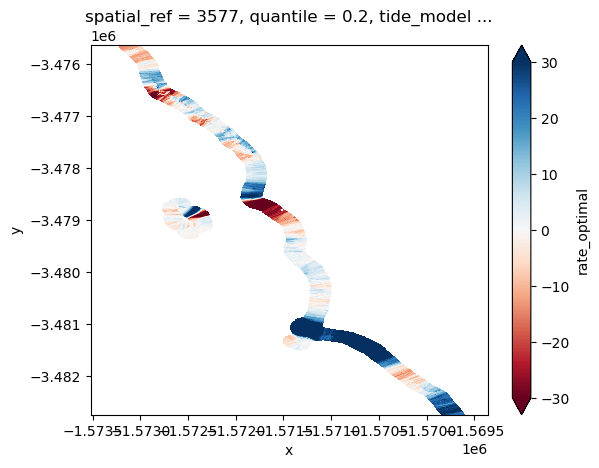

In [52]:
rate_change_original.rate_optimal.plot(vmin=-30, vmax=30, cmap="RdBu")

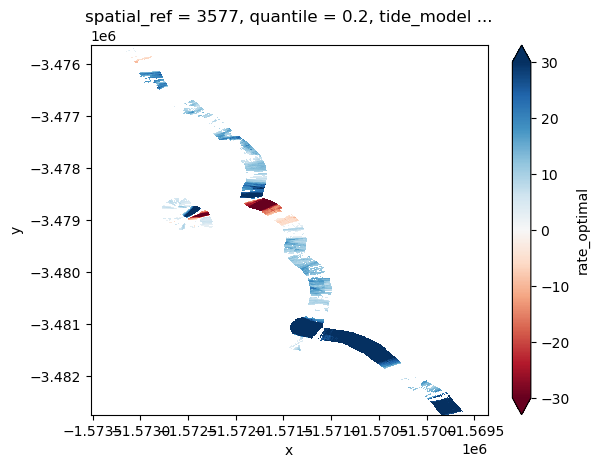

In [63]:
rate_change_corrected.rate_optimal.where(rate_change_corrected.rate_significance).plot(vmin=-30, vmax=30, cmap="RdBu")

In [ ]:
rate_change_corrected.rate_significance.plot()

In [ ]:
rate_change_corrected.rate_uncertainty.plot(vmin=0, vmax=20)

In [ ]:
(rate_change_original.rate_uncertainty - rate_change_corrected.rate_uncertainty).plot(vmin=-10, vmax=10, cmap="RdBu")

In [55]:
rate_change_corrected.rate_optimal.odc.write_cog("data/rate_change.tif", overwrite=True)

PosixPath('data/rate_change.tif')

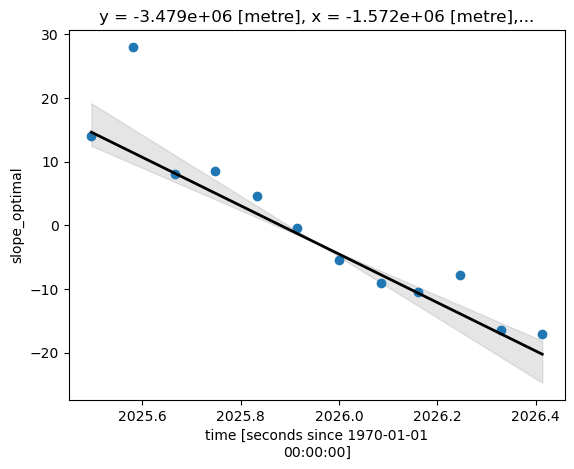

In [54]:
import matplotlib.pyplot as plt

x, y = -1571690.22,-3478727.76
alpha = 0.9

# Extract valid x and y values
pixel_ds = sdf_corrected_monthly.sel(x=x, y=y, method="nearest")
valid_ds = pixel_ds.dropna(dim="time")
x_vals = valid_ds.time.dt.decimal_year

# Calculate the center of mass (the pivot point)
med_x = np.median(x_vals)

# Calculate rates
rates_ds = calculate_rate_of_change(sdf_stack=valid_ds, alpha=alpha)

# Determine the median y-value directly from the optimal regression line
med_y = rates_ds.rate_optimal * med_x + rates_ds.rate_intercept

# Calculate independent intercepts for the upper and lower bounds 
# forcing them to pivot through the center of the data
intercept_high = med_y - (rates_ds.rate_high * med_x)
intercept_low = med_y - (rates_ds.rate_low * med_x)

# Calculate the final plotting arrays
y_opt = rates_ds.rate_optimal * x_vals + rates_ds.rate_intercept
y_high = rates_ds.rate_high * x_vals + intercept_high
y_low = rates_ds.rate_low * x_vals + intercept_low

# Proceed with plotting...
valid_ds["time"] = x_vals
(-valid_ds).plot(linestyle='none', marker='o')

plt.fill_between(
        x_vals,
        y_low,
        y_high,
        color="gray",
        alpha=0.2,
        label=f"{int(alpha*100)}% Confidence Interval",
    )
plt.plot(
        x_vals,
        y_opt,
        color="black",
        linewidth=2,
)

In [ ]:
sdf_corrected  # xarray.Dataset, dims: (time, y, x)

# Intertidal mask — pixels that transition sign in the corrected stack
intertidal_mask = (
    (sdf_corrected.min("time") < 0) &
    (sdf_corrected.max("time") > 0)
)

# Mean shoreline at 0m AMSL
mean_shoreline_sdf = sdf_corrected.mean("time")

# Temporal variability — residual noise + morphodynamic activity
variability = sdf_corrected.std("time")

In [ ]:
variability.odc.explore()

In [ ]:
# n_sigma *
tide_range = tides_da.max(dim="time") - tides_da.min(dim="time")

# (2 / 0.01)

#### Instantaneous shorelines

In [ ]:
subpixel_contours(
    sdf_da,
    attribute_df=tides_da.median(dim=["x", "y"]).to_dataframe()[["tide_height"]].reset_index(drop=True),
    output_path="shorelines_original.geojson",
    min_vertices=20,
)

subpixel_contours(
    sdf_corrected,
    attribute_df=tides_da.median(dim=["x", "y"]).to_dataframe()[["tide_height"]].reset_index(drop=True),
    output_path="shorelines_corrected.geojson",
    min_vertices=20,
)